# Gemini I
## Introducción a prompting

Guía práctica enfocada en cómo diseñar, probar y optimizar prompts efectivos. 

## Importar librerías

En Python, importar librerías es una de las primeras partes de un código, ya que permite acceder a funciones y herramientas ya desarrolladas. Estas librerías contienen módulos específicos para realizar tareas como operaciones matemáticas, manejo de datos, visualización gráfica, entre otros. Importarlas al inicio del código garantiza que todas las funcionalidades necesarias estén disponibles, lo que ahorra tiempo y mejora la eficiencia.

pip install --upgrade google-cloud-aiplatform

In [1]:
import pandas as pd
import json
import time
import io
import os
from google import genai
from google.genai import types
from google.genai.types import GenerateContentConfig, ThinkingConfig, SafetySetting, CreateBatchJobConfig, JobState, HttpOptions, EmbedContentConfig

## Inicializar variables

Esta celda configura los parámetros necesarios para trabajar con servicios en la nube, como el almacenamiento, el proyecto activo, la ubicación geográfica y el modelo de inteligencia artificial que se utilizará. Estos valores son fundamentales para garantizar que las operaciones posteriores se realicen en el entorno correcto.

In [ ]:
GEMINI_API_KEY=''
MODEL_ID = "gemini-3-flash-preview"

In [3]:
# Cargar datos
df = pd.read_csv("Big_AHR.csv", sep=',')
df.head()

,Unnamed: 0,title,rating,review_text,location,hotel,label
0,0,Excelente y personal amable,5,Un hotel muy bueno. El personal fue muy amabl...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
1,1,Céntrico,4,"Muy buen hotel al nivel de lo esperado, habita...",Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
2,2,Hotel excepcional,5,Magnífico hotel. La verdad es que todo perfect...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
3,3,WOW!!,5,"Hotel hermoso, buen diseño, original, limpio. ...",Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
4,4,Magnifico,5,Magnífica ubicación en pleno centro de Sevilla...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1


# Introducción a Gemini

Gemini es una familia de modelos avanzados de inteligencia artificial multimodal generativa desarrollada por Google, diseñada para entender y trabajar con diferentes tipos de información como texto, imágenes, audio, video y código.  Funciona como un asistente conversacional. 

Antes de poder usar Gemini, es necesario inicializar el cliente que se conecta con Vertex AI:

In [6]:

client = genai.Client(api_key=GEMINI_API_KEY)
model = MODEL_ID

## Primer prompt

En el siguiente código se envía una solicitud al modelo y se muestra la respuesta generada.

In [7]:
prompt = "Dime cómo estás en una sola frase."

response = client.models.generate_content(
    model=model, contents=prompt
)

print(response.text)

Estoy muy bien y listo para ayudarte con lo que necesites.


## Componentes de un prompt

Un buen prompt ayuda a los modelos de IA a generar respuestas más precisas y útiles. Para lograrlo, es importante tener en cuenta los siguientes componentes:
- **Persona:** Define el tono y la voz desde la perspectiva deseada. Esto le indica al modelo quién debe “ser” al responder *(ej. Eres un director de ingeniería).*
- **Tarea:** Describe con claridad qué quieres obtener. Puede ser algo simple (una lista) o complejo (un plan detallado). *(ej. Explica paso a paso cómo mejorar la experiencia del usuario en una app bancaria)*
- **Contexto:** Proporciona detalles y restricciones que ayuden al modelo a entender la situación. Cuanta más información, mejor. *(ej. …para el CFO que no está familiarizado con el proyecto)*
- **Formato:** Indica cómo quieres que se presente la respuesta: tabla, lista con viñetas, párrafo, esquema, etc.

## Configuración de parámetros

Cuando se usa un modelo de inteligencia artificial como Gemini para generar texto, es posible controlar cómo se comporta el modelo. Esto se logra utilizando una herramienta llamada GenerateContentConfig, que permite ajustar ciertos parámetros que afectan el estilo, la creatividad, la precisión y la longitud de la respuesta que va a generar el modelo. Es muy útil si se quiere que el modelo dé respuestas más creativas, más breves o más detalladas.

Uno de los parámetros más importantes es la **temperature**, que controla lo creativa o aleatoria que es la respuesta. Si el valor es bajo (por ejemplo, 0.2), el modelo tenderá a dar respuestas más lógicas y predecibles. Si es más alto (por ejemplo, 1.5), las respuestas pueden ser más variadas o inesperadas. Otro parámetro clave es **max_output_tokens**, que define la longitud máxima de la respuesta. Esto es útil si se quiere asegurar que el modelo no se extienda demasiado.

También existen parámetros como **top_p** y **top_k**, que controlan cuántas opciones considera el modelo al elegir la siguiente palabra. top_k limita el número de palabras candidatas más probables que el modelo puede elegir. Por ejemplo, si top_k es 40, el modelo solo elegirá entre las 40 palabras más probables. El parámetro top_p controla cuántas palabras posibles puede considerar el modelo según la suma de sus probabilidades. Por ejemplo, si top_p es 0.9, el modelo seleccionará entre el grupo más pequeño de palabras cuya probabilidad acumulada sea al menos de 90%. top_p hace una selección basada en la probabilidad acumulada, lo que permite respuestas más naturales si se ajusta correctamente.

Finalmente, el parámetro **stop_sequences** permite indicar una o varias secuencias de texto que, al ser generadas por el modelo Gemini, harán que la respuesta se detenga automáticamente. Esto ayuda a controlar la longitud del texto y evitar que el modelo continúe generando contenido innecesario. Por ejemplo, si ponemos stop_sequences=["\n\n"], la generación terminará cuando el modelo empiece un nuevo párrago. Así se logra un mayor control sobre dónde y cuándo finalizar la respuesta.

A través del uso de estos parámetros dentro de **GenerateContentConfig**, podemos lograr que el modelo se adapte mejor a lo que necesitamos. Por ejemplo, si estamos creando una aplicación educativa, tal vez queremos respuestas claras y precisas. Pero si queremos que nos genere una historia original, nos interesará que el modelo sea más creativo y flexible.



### Efecto del parámetro *max_output_tokens*

In [12]:
generation_config = GenerateContentConfig(
    temperature = 0.7,
    top_p = 0.95,
    top_k = 40,
    max_output_tokens = 100,
    thinking_config=ThinkingConfig(
        thinking_budget=0     # 0 apaga en; -1 automático
    )
)

prompt = "Explicame por que el cielo es azul."

response = client.models.generate_content(
    model=model, config=generation_config, contents=prompt
)
print(response.text)

La explicación de por qué el cielo es azul se debe a un fenómeno científico llamado **Dispersión de Rayleigh**.

Aquí te lo explico paso a paso de forma sencilla:

### 1. La luz del sol es un arcoíris
Aunque vemos la luz del sol como "blanca", en realidad está compuesta por todos los colores del arcoíris (rojo, naranja, amarillo, verde, azul, añil y violeta). Cada color viaja


Podemos ver que la salida queda incompleta, ya que el parámetro de configuración max_output_tokens limita la respuesta generada por Gemini a 100 tokens. Para obtener una respuesta completa, se podría aumentar este límite o indicar explícitamente en el prompt que la respuesta debe ser breve y concisa.

### Efecto del parámetro *stop_sequencies*

In [13]:
generation_config = GenerateContentConfig(
    temperature=0.7,
    top_p=0.95,
    top_k=40,
    max_output_tokens=200,
    stop_sequences=["\n\n"],  
    thinking_config=ThinkingConfig(
        thinking_budget=0  # 0 = desactiva, -1 = automático
    )
)

prompt = "Explicame por que el cielo es azul."

response = client.models.generate_content(
    model=model, config=generation_config, contents=prompt
)
print(response.text)

La explicación de por qué el cielo es azul se debe a un fenómeno científico llamado **Dispersión de Rayleigh**.


El modelo deja de generar texto cuando tiene un salto de línea. 

### Efecto del parámetro de temperatura

En la siguiente sección, se observa cómo varía la respuesta del modelo al modificar el parámetro de temperatura cuando se le solicita generar una historia creativa.

#### Temperature alta

In [14]:
# Configurar parámetros del modelo
generation_config = GenerateContentConfig(
    temperature=1.9
)

# Definir el prompt
prompt = "Escribe una breve historia sobre un sapo"

# Enviar un prompt
response = client.models.generate_content(
    model=model, config=generation_config, contents=prompt
)

# Mostrar la respuesta generada
print(response.text)

Había una vez un pequeño pingüino llamado Pipo que vivía en la inmensidad de la Antártida. A diferencia de sus amigos, que pasaban el día compitiendo por ver quién atrapaba el pez más grande, Pipo era un soñador. Él pasaba horas mirando hacia el cielo, fascinado por las aves que volaban sobre el océano.

—¿Por qué tenemos alas si no podemos volar? —le preguntaba Pipo a su abuelo.

El abuelo, un pingüino sabio de plumas grisáceas, sonreía y le respondía:
—Pipo, nosotros no volamos en el aire, sino en el cristal líquido. Espera a que seas más grande y lo entenderás.

Un día, llegó el momento del primer chapuzón de Pipo en el océano profundo. Al principio, tenía miedo. El agua parecía fría y oscura, pero en cuanto se lanzó desde el borde del hielo, algo mágico sucedió.

Pipo cerró los ojos un segundo y, al abrirlos bajo el agua, estiró sus alas. De repente, no se sentía pesado ni torpe como en la nieve. Se sentía ligero, rápido y elegante. Esquivó una corriente con un giro perfecto y se i

#### Temperature baja

In [15]:
# Configurar parámetros del modelo
generation_config = GenerateContentConfig(
    temperature=0.1,
)

# Definir el prompt
prompt = "Escribe una breve historia sobre un sapo"

# Enviar un prompt
response = client.models.generate_content(
    model=model, config=generation_config, contents=prompt
)

# Mostrar la respuesta generada
print(response.text)

Aquí tienes una breve historia sobre un pingüino:

**Pipo y el Salto al Azul**

Pipo no era un pingüino común; era el más precavido de toda la colonia en la Antártida. Mientras sus amigos se lanzaban al gélido océano con piruetas dignas de un circo, Pipo se quedaba en la orilla, mirando sus patas naranjas con desconfianza.

—¡El agua está deliciosa, Pipo! —gritaba su amiga Luna, emergiendo con un pez plateado en el pico.

Pipo suspiraba. Para él, el mar parecía un monstruo gigante que tragaba pingüinos. Pero ese día, el hambre era más fuerte que el miedo. Se acercó al borde del acantilado de hielo. El azul del agua brillaba bajo el sol austral, reflejando destellos de luz que parecían diamantes.

Cerró los ojos con fuerza, tomó aire y, justo cuando iba a dar media vuelta para volver a su nido, una ráfaga de viento juguetona lo empujó.

¡Splash!

El frío lo envolvió de golpe, pero no fue aterrador. Al abrir los ojos bajo el agua, Pipo descubrió un mundo mágico. Sus alas, que en tierra e

### Thinking

Los modelos generan un proceso de pensamiento interno para reforzar el razonamiento. El parámetro thinking permite definir el nivel de razonamiento que queremos que el modelo aplique a la hora de generar la respuesta, hay que tener en cuenta que el reasoning aplicado genera más tokens y por lo tanto aumenta el coste final, por lo que es recomendable que en casos de uso donde el nivel de razonamiento sea predecible establezcamos límites de thinking para controlar esos tokens.

- **Cómo deshabilitar/controlar “thinking” (Python):** con `ThinkingConfig(...)` dentro de `GenerateContentConfig`.  
  - `include_thoughts=True` para ver resúmenes de pensamientos.
  - `thinking_budget`: controla el presupuesto de pensamiento (tokens). `0` lo apaga, `-1` deja el presupuesto en automático.  


In [16]:
generation_config = GenerateContentConfig(
        thinking_config=ThinkingConfig(
            include_thoughts=True,  # mostrar pensamientos/resumen
            thinking_budget=512     # 0 apaga en; -1 automático
        )
)

prompt = '''Cuántas A tiene la palabra Amapola?'''

response = client.models.generate_content(
    model=model, config=generation_config, contents=prompt
)
print(response.text)

# Mostrar (si hay) fragmentos del "thought process" devueltos por el modelo
print("\n=== Pensamientos (resumen) ===")
for part in response.candidates[0].content.parts:
    if getattr(part, "thought", None):
        print(part.text)

La palabra **Amapola** tiene **3** letras "a".

Aquí puedes verlas resaltadas: **A**m**a**pol**a** (una mayúscula y dos minúsculas).

=== Pensamientos (resumen) ===
**Counting "A"s in "Amapola"**

Okay, so the target word is "Amapola," and my task is to meticulously count every instance of the letter "A," regardless of its case. Let's break this down. First, I see an uppercase "A" at the beginning – that's one. Then, skipping over "m," I hit a lowercase "a" – that’s now two. Moving along, I note that "p," "o," and "l" are irrelevant to my task. Finally, the word ends with a lowercase "a" which makes three. Therefore, there are three "A"s in total, one uppercase and two lowercase, in the word "Amapola". The answer is a simple 3.





## Configuración de los filtros de seguridad

Los filtros de seguridad son mecanismos integrados en los modelos de lenguaje que sirven para limitar la generación de contenido dañino o inapropiado. Estos filtros evalúan la salida del modelo en función de categorías de daño, como violencia, acoso, discurso de odio o contenido sexual explícito.

Cada categoría puede configurarse con un umbral de sensibilidad, que determina qué tan estricto será el filtro.
Por ejemplo, el umbral BLOCK_ONLY_HIGH indica que solo se bloquearán las respuestas si el riesgo de daño es alto, mientras que BLOCK_LOW_AND_ABOVE bloqueará incluso los casos con riesgo bajo o moderado. Estos ajustes permiten encontrar un equilibrio entre la creatividad del modelo y la protección del usuario frente a contenido inapropiado.



| Umbral (Google AI Studio) | Umbral (API)                       | Descripción |
|----------------------------|------------------------------------|--------------|
| **Desactivado**            | `OFF`                              | Desactiva el filtro de seguridad. |
| **No bloquear**            | `BLOCK_NONE`                       | Muestra siempre, sin importar la probabilidad de que sea contenido no seguro. |
| **Bloquear poco**          | `BLOCK_ONLY_HIGH`                  | Bloquea cuando hay una **alta** probabilidad de que el contenido sea no seguro. |
| **Bloquear algo**          | `BLOCK_MEDIUM_AND_ABOVE`           | Bloquea cuando hay una probabilidad **media o alta** de contenido no seguro. |
| **Bloquear la mayoría**    | `BLOCK_LOW_AND_ABOVE`              | Bloquea cuando hay una probabilidad **baja, media o alta** de contenido no seguro. |
| **N/A**                    | `HARM_BLOCK_THRESHOLD_UNSPECIFIED` | No se especifica el umbral; se usa el valor predeterminado. |

En el siguiente ejemplo, se definen los ajustes de seguridad antes de pedirle al modelo que escriba una historia con un conflicto violento. Esto asegura que, si el contenido generado es demasiado explícito o potencialmente dañino, el modelo lo detecte y lo bloquee o modere automáticamente.


In [17]:
# Configurar filtros de seguridad
# block_low_and_above
safety_settings = [
    SafetySetting(category="HARM_CATEGORY_DANGEROUS_CONTENT", threshold="BLOCK_ONLY_HIGH"),  
    SafetySetting(category="HARM_CATEGORY_SEXUALLY_EXPLICIT", threshold="BLOCK_ONLY_HIGH"),
    SafetySetting(category="HARM_CATEGORY_HARASSMENT", threshold="BLOCK_ONLY_HIGH"),
    SafetySetting(category="HARM_CATEGORY_HATE_SPEECH", threshold="BLOCK_ONLY_HIGH"),
]

# Configurar parámetros del modelo
generation_config = GenerateContentConfig(
    max_output_tokens=500,
    safety_settings=safety_settings,
    thinking_config=ThinkingConfig(
            thinking_budget=0     # 0 apaga en; -1 automático
        )
)

prompt = "Escribe una historia corta en unas 20 lineas, que incluya un conflicto violento entre dos personajes."

response = client.models.generate_content(
    model=model, config=generation_config, contents=prompt
)

print(response.text)

El aire en el almacén abandonado olía a óxido y pólvora. Marco sostenía la bolsa con el dinero, pero sus nudillos blancos delataban que no planeaba entregarla. Frente a él, Elías mantenía el dedo índice rozando el gatillo de su revólver, con los ojos inyectados en sangre por la traición.

—Suéltala, Marco. No me obligues a vaciarte el pecho —gruñó Elías, dando un paso corto sobre los cristales rotos.
—Tú ya estás muerto, Elías. Solo que aún no te has caído —respondió el otro con una sonrisa cínica.

El primer disparo retumbó contra las paredes de chapa, un estallido sordo que rozó la oreja de Marco. Sin dudar, este lanzó la pesada bolsa hacia el rostro de su oponente como distracción y se abalanzó sobre él. Chocaron con la fuerza de dos locomotoras, rodando por el suelo polvoriento entre gritos de rabia.

Marco logró encajar un puñetazo brutal en la mandíbula de Elías, escuchando el crujido del hueso. Elías respondió clavándole los dedos en los ojos y estrellando su rodilla contra el e

## Establecer instrucciones del sistema

Además, opcionalmente se pueden incluir instrucciones para el sistema incorporandolas directamente dentro del propio prompt en forma de una frase o párrafo inicial. Incluir las instrucciones en el prompt es una forma práctica de guiar el comportamiento del modelo, ya que al hacerlo le proporcionas un contexto adicional que facilita una mejor comprensión de la tarea y permite generar respuestas más personalizadas.

In [18]:
# Junta la instrucción del sistema dentro del prompt
prompt = """
Eres un traductor de idiomas útil.
Tu misión es traducir texto del español al inglés.

Entrada del usuario: Me gustan los bagels.
Respuesta:
"""

generation_config = GenerateContentConfig(
    temperature=0.5,
    max_output_tokens=256,
    thinking_config=ThinkingConfig(
            thinking_budget=0     # 0 apaga en; -1 automático
        )
)

response = client.models.generate_content(
    model=model, config=generation_config, contents=prompt
)

print(response.text)

I like bagels.


## Output estructurado

A veces, no es suficiente con que el modelo genere texto libre, y necesitamos que devuelva la información estructurada (como si fuera una tabla, un diccionario o un JSON). Para hacerlo, se usa la función **response_schema**, que permite definir la estructura esperada de la respuesta. Así el modelo sabe que debe seguir un formado específico, con campos y tipos definidos. 
Esto es útil para tareas como extracción de datos, clasificación o cualquier situación donde necesitas que el modelo no solo genere texto libre, sino que devuelva datos bien organizados.

In [19]:
# Generar output estructurado
response_schema = {
    "type": "array", #  Especifica que esperarás una lista/array de objetos.
    "items": {       #  Define la estructura de cada elemento dentro de la lista.
        "type": "object", 
        "properties": { 
            "pais": {"type": "string"},
            "capital": {"type": "string"},
            "poblacion_millones": {"type": "number"}
        },
        "required": ["pais", "capital", "poblacion_millones"]  # Campos obligatorios en cada objeto
    }
}

# Configurar parámetros del modelo
generation_config = GenerateContentConfig(
    max_output_tokens=500,
    response_mime_type="application/json", #la salida debe ser json
    response_schema=response_schema,
    thinking_config=ThinkingConfig(
            thinking_budget=0     # 0 apaga en; -1 automático
        )
)

prompt = "Genera una lista de 3 países con sus capitales y población aproximada en millones."

response = client.models.generate_content(
    model=model, config=generation_config, contents=prompt
)

response_text = response.text
result = json.loads(response_text)
print(result)

[{'pais': 'España', 'capital': 'Madrid', 'poblacion_millones': 47.5}, {'pais': 'México', 'capital': 'Ciudad de México', 'poblacion_millones': 126.7}, {'pais': 'Argentina', 'capital': 'Buenos Aires', 'poblacion_millones': 45.8}]


## Batch prediction

Batch prediction permite procesar grandes volúmenes de datos con Gemini de forma más económica y eficiente.
En lugar de enviar cada solicitud al modelo una por una (como en tiempo real), se pueden enviar diversas peticiones en un solo trabajo, y el sistema las procesa en paralelo, devolviendo los resultados cuando todo termina.

Esto tiene 3 ventajas:
- Más económico: Reducir costes hasta un 50%
- Mayor capacidad: Permite procesar ratios de información más altos (miles de peticiones en un único batch)
- Flujo de trabajo más simple: Permite orquestar de manera más sencilla (sin manejar miles de llamadas individuales), en lugar de crear workflows, cuando el proceso batch finaliza se puede seguir con el flujo sin tener que controlar por ejemplo los retries si falla la petición a Gemini. A pesar de que la documentación oficial menciona un tiempo de procesamiento de hasta 24 horas para los batch prediction jobs, en nuestras pruebas los tiempos reales de respuesta han sido significativamente menores, normalmente entre unos minutos y unas pocas horas.

Se muestra un ejemplo detallado en la segunda parte de la guía - Lab 2: Ejemplos de aplicaciones y casos reales de uso.

📖 Más detalles en la documentación oficial:  
[Batch Prediction Gemini | Generative AI on Vertex AI](https://cloud.google.com/vertex-ai/generative-ai/docs/multimodal/batch-prediction-gemini)



## Context cache 

Al trabajar con modelos de lenguaje como Gemini, muchas veces los prompts incluyen parte del mismo contenido repetido. Por ejemplo, un texto largo con instrucciones del sistema o información base que usas en cada llamada.

Cada vez que se manda ese contenido, el modelo tiene que volver a procesarlo, lo que aumenta el coste y el tiempo de respuesta. Para resolver esto, Vertex AI ofrece una función llamada **context caching**. Esto permite guardar (en caché) esa parte repetitiva del prompt para no tener que volver a enviarla ni pagar por ella cada vez.
Así, las siguientes solicitudes que usen ese mismo contenido se procesan más rápido y más barato.

El context caching es especialmente útil cuando se trabaja con grandes contextos que se repiten en muchas consultas. Algunos ejemplos típicos:
- Chatbots que usan las mismas instrucciones del sistema en cada interacción.
- Análisis repetido de videos, documentos o grandes textos.
- Consultas periódicas a un conjunto fijo de archivos o código fuente.
- Procesos que generan múltiples respuestas sobre el mismo contexto base (por ejemplo, varias preguntas sobre el mismo artículo o dataset).

📖 Más detalles en la documentación oficial:  
[Context Cache | Generative AI on Vertex AI ](https://cloud.google.com/vertex-ai/generative-ai/docs/context-cache/context-cache-overview)

# Técnicas para generar prompts 

La generación eficaz de un prompt es un proceso iterativo que requiere pruebas constantes para optimizar los resultados y adaptarse a la tarea específica. Es fundamental comenzar con instrucciones claras y directas que definan con precisión lo que se espera del modelo. Por ejemplo, en lugar de pedir simplemente "traducir", es mucho más efectivo especificar: "Traduce el siguiente texto al español: 'Hello!'". Esta claridad reduce la ambigüedad y mejora la calidad de las respuestas generadas.

Al escribir un buen prompt para Gemini, es importante tener en cuenta que el modelo responde mejor cuando se le proporciona un contexto bien estructurado y una tarea claramente delimitada. Gemini está optimizado para comprender instrucciones detalladas y manejar múltiples modalidades, por lo que conviene ser preciso en la formulación del objetivo, especificar el formato de salida esperado y, si es necesario, dividir tareas complejas en pasos más simples. Además, incluir indicaciones sobre el estilo o nivel de profundidad deseado puede marcar una diferencia en la calidad de la respuesta.

Las técnicas más utilizadas para crear prompts son:

- **Zero-shot prompting**: se solicita al modelo que realice una tarea sin proporcionarle ejemplos previos, confiando únicamente en la instrucción explícita. Esta técnica es útil cuando no se tienen ejemplos o cuando se quiere evaluar la capacidad general del modelo.

- **Few-shot prompting**: se incluyen uno o varios ejemplos concretos antes de la tarea para que el modelo comprenda mejor el formato y el tipo de respuesta esperado. Esto suele mejorar la precisión y coherencia, especialmente en tareas más complejas o especializadas. Es importante destacar que **one-shot prompting** es una version de few-shot prompting que consiste en darle al modelo exactamente un solo ejemplo junto con la instrucción.

- **Chain-of-thought prompting (cadena de pensamiento)**: se anima al modelo a explicar su razonamiento paso a paso antes de entregar una respuesta final. Esta técnica es especialmente eficaz para problemas que requieren análisis lógico o secuencial, ya que facilita un mejor entendimiento de tareas complejas.

Además, la iteración constante es clave: tras probar un prompt inicial, se evalúan las respuestas y se ajusta el texto para corregir errores, añadir contexto relevante o simplificar instrucciones. 
En definitiva, combinar estas técnicas y adaptar el prompt de manera dinámica permite aprovechar al máximo las capacidades del modelo, logrando respuestas más precisas, coherentes y útiles.

Estas son las mejores practicas en prompt engineering:
- Ser conciso
- Ser específico y definir bien lo que quieres
- Pedir una sola tarea a la vez
- Transformar tareas generativas en tareas de clasificación
- Mejorar la calidad de la respuesta incluyendo ejemplos

En esta sección ya podemos observar una de las múltiples capacidades de Gemini: la clasificación de un texto según su sentimiento.

## Ejemplo zero-shot prompting

In [20]:
prompt = """Dado el siguiente extracto de texto, identifica el sentimiento predominante (positivo, negativo o neutral):  
"El servicio al cliente fue rápido, pero el producto llegó dañado"."""  

response = client.models.generate_content(
    model=model, contents=prompt
)

print(response.text)

El sentimiento predominante es **negativo** (o **mixto**).

**Razonamiento:** Aunque el texto menciona un aspecto positivo ("servicio rápido"), el problema principal ("producto dañado") tiene mayor peso en la experiencia del cliente, lo que suele inclinar la balanza hacia una percepción negativa o de insatisfacción. En un análisis más detallado, se clasificaría como "mixto" con una fuerte inclinación negativa.


## Ejemplo one-shot prompting

In [21]:
prompt = """Aqui tienes un texto acompañado de su clasificación de sentimiento. Con base en este ejemplo, determina el sentimiento predominante (positivo, negativo o neutral) del texto que se presenta al final.

Ejemplos:  
Texto: "La atención en la tienda fue excelente y muy rápida."  
Sentimiento: Positivo  

Ahora clasifica el siguiente texto:  
"El servicio al cliente fue rápido, pero el producto llegó dañado."  
Sentimiento:

"""

response = client.models.generate_content(
    model=model, contents=prompt
)

print(response.text)

Sentimiento: **Neutral** (o Mixto)


## Ejemplo few-shot prompting

In [22]:
prompt = """A continuación se presentan varios textos con su correspondiente clasificación de sentimiento. En base a estos ejemplos, clasifica el sentimiento predominante (positivo, negativo o neutral) del siguiente texto.

Ejemplos:  
Texto: "Me encantó la película, fue muy emocionante."  
Sentimiento: Positivo  

Texto: "El paquete llegó tarde y sin los accesorios."  
Sentimiento: Negativo  

Texto: "La comida estaba bien, pero el servicio fue lento."  
Sentimiento: Neutral  

Ahora clasifica el siguiente texto:  
"El servicio al cliente fue rápido, pero el producto llegó dañado."  
Sentimiento:
"""

response = client.models.generate_content(
    model=model, contents=prompt
)

print(response.text)

**Sentimiento:** Neutral


## Ejemplo chain-of-thought prompting

In [23]:
prompt = """ Pregunta: Si un coche recorre 60 km en 1 hora y luego 90 km en 1.5 horas, ¿cuál es su velocidad promedio?  
Explica paso a paso cómo calcular la velocidad promedio antes de dar la respuesta final. """

response = client.models.generate_content(
    model=model, contents=prompt
)

print(response.text)

Para calcular la velocidad promedio, no basta con promediar las velocidades de cada tramo; debemos usar la fórmula general de la velocidad promedio, que es:

$$\text{Velocidad promedio} = \frac{\text{Distancia total recorrida}}{\text{Tiempo total empleado}}$$

Aquí tienes los pasos detallados:

### Paso 1: Calcular la distancia total
Primero, sumamos las distancias de los dos tramos del viaje:
*   Primer tramo: 60 km
*   Segundo tramo: 90 km
*   **Distancia total** = 60 km + 90 km = **150 km**

### Paso 2: Calcular el tiempo total
Ahora, sumamos el tiempo que tomó cada tramo:
*   Primer tramo: 1 hora
*   Segundo tramo: 1.5 horas
*   **Tiempo total** = 1 hora + 1.5 horas = **2.5 horas**

### Paso 3: Aplicar la fórmula de velocidad promedio
Dividimos la distancia total entre el tiempo total:
*   Velocidad promedio = $150\text{ km} / 2.5\text{ horas}$

Haciendo la división:
$150 \div 2.5 = 60$

***

**Respuesta final:**
La velocidad promedio del coche es de **60 km/h**.





Como se ha detallado a lo largo de la guía, el **diseño de prompts** suele ser un proceso iterativo que requiere revisarse cuando se cambian los modelos o incluso ciertos parámetros.  En el siguiente enlace se encuentra un resumen de las técnicas y buenas prácticas, que se recomienda tenerlas en cuenta en función del propósito. 

[Overview of prompting strategies | Generative AI on Vertex AI](https://cloud.google.com/vertex-ai/generative-ai/docs/learn/prompts/prompt-design-strategies). 

# Recursos complementarios en Vertex AI Studio

Las funciones *Prompt Agent* y *Compare*, son dos herramientas adicionales disponibles en Vertex AI Studio para ayudar a optimizar y escribir mejores prompts. 

### ✨ Función *Prompt Agent* en Vertex AI Studio

En **Vertex AI Studio** se encuentra la función **“Prompt Agent”** (Agente de instrucciones), que actúa como asistente de IA para ayudarte a mejorar tus *prompts*.  

Esta herramienta permite:

- Generar prompts sugeridos a partir de una descripción breve.  
- Refinar prompts existentes (más claros, más concisos o más profesionales).  
- Ajustar hasta obtener el resultado que buscas.  

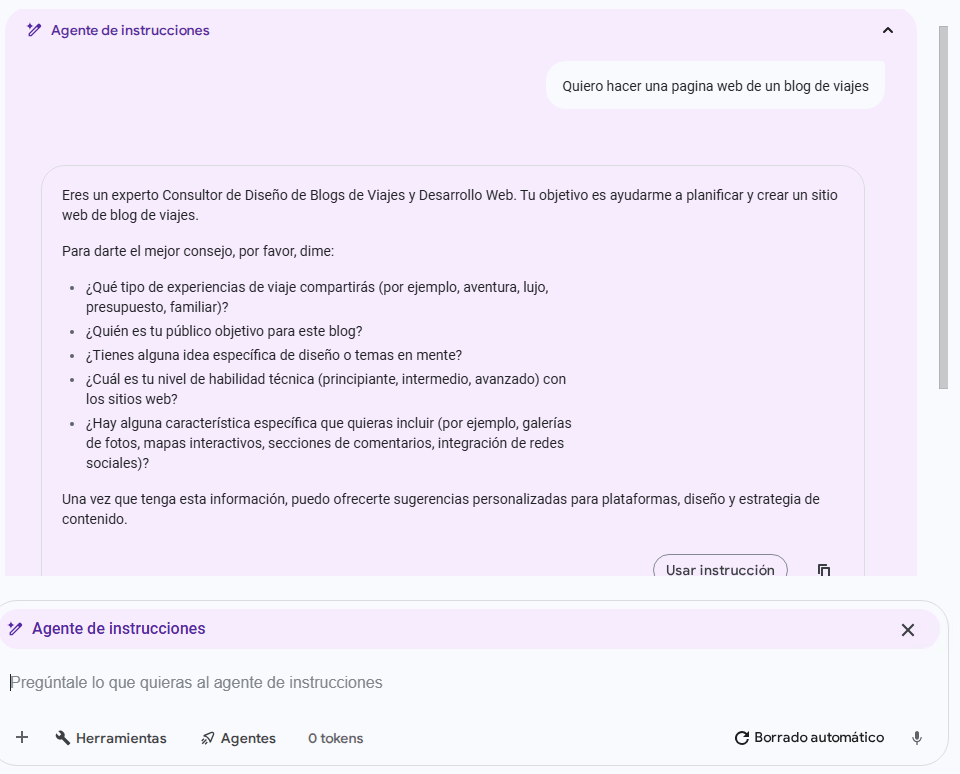

📖 Más detalles en la documentación oficial:  
[Use AI-powered prompt writing tools | Generativa AI on Vertex AI](https://cloud.google.com/vertex-ai/generative-ai/docs/learn/prompts/ai-powered-prompt-writing)


### ✨ Función *Compare* en Vertex AI Studio  

La función **Compare** en Vertex AI Studio no solo permite evaluar modelos distintos,  sino también **probar variaciones de parámetros de generación** en paralelo, como:  

- **Temperature** → controla la aleatoriedad en las respuestas (más alto = más creativo, más bajo = más determinista).  
- **Top-p** → ajusta la probabilidad acumulada de palabras candidatas (útil para afinar la diversidad).  
- **Max output tokens** → define la extensión máxima de la salida.  
- **Top-k** → limita el número de palabras candidatas consideradas.  
- **System instructions** → permiten establecer diferentes contextos, estilos o comportamientos del modelo.

Con *Compare* puedes:  

- Configurar diferentes combinaciones de parámetros.  
- Generar salidas simultáneas para la **misma entrada**.  
- Analizar lado a lado cómo cambian el **tono, la precisión o la creatividad**.  
- Seleccionar la configuración más adecuada para tu caso de uso (ej. respuestas precisas vs. creativas).  

En resumen, *Compare* facilita la **exploración y optimización tanto de los hiperparámetros como del comportamiento del modelo**, permitiendo entender de manera práctica cómo cada ajuste afecta los resultados generados.  

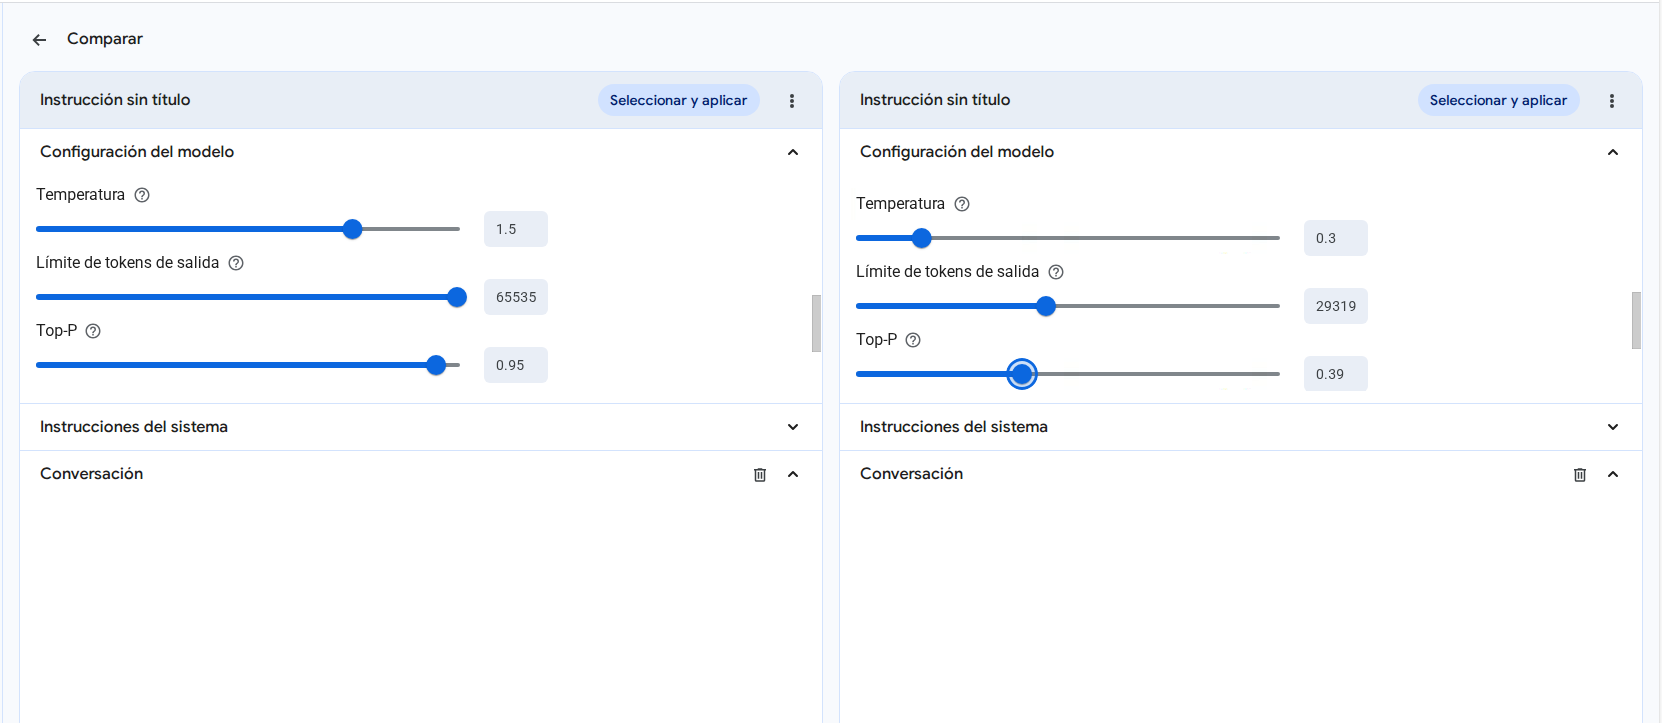

📖 Más detalles en la documentación oficial:  
[Use AI-powered prompt writing tools | Generative AI on Vertex AI](https://cloud.google.com/vertex-ai/generative-ai/docs/learn/prompts/compare-prompts?hl=es)